# **Data upload from google drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
file_path = '/content/drive/MyDrive/AAI500_Module 4/CDC_data/diabetes_012_health_indicators_BRFSS2015.csv'
df = pd.read_csv(file_path)
print(df.head(10))
df.describe()
df.shape
print(df.loc[df['Diabetes_012'] == 1].shape) # in the binary , it was combined with 0 to become 218334
print(df.loc[df['Diabetes_012'] == 0].shape)
print(df.loc[df['Diabetes_012'] == 2].shape) #only keep this one as the diabete group
#combine the prediabete to non diabete
df.head(10)
df.loc[df["Diabetes_012"]==1, "Diabetes_012"] = 0
df.loc[df["Diabetes_012"]==2, "Diabetes_012"] = 1
df["Diabetes_012"].value_counts()

# **Data preprocessing**

since there are three types of data

– Ordinal data type

– binary data type

– numerical data type

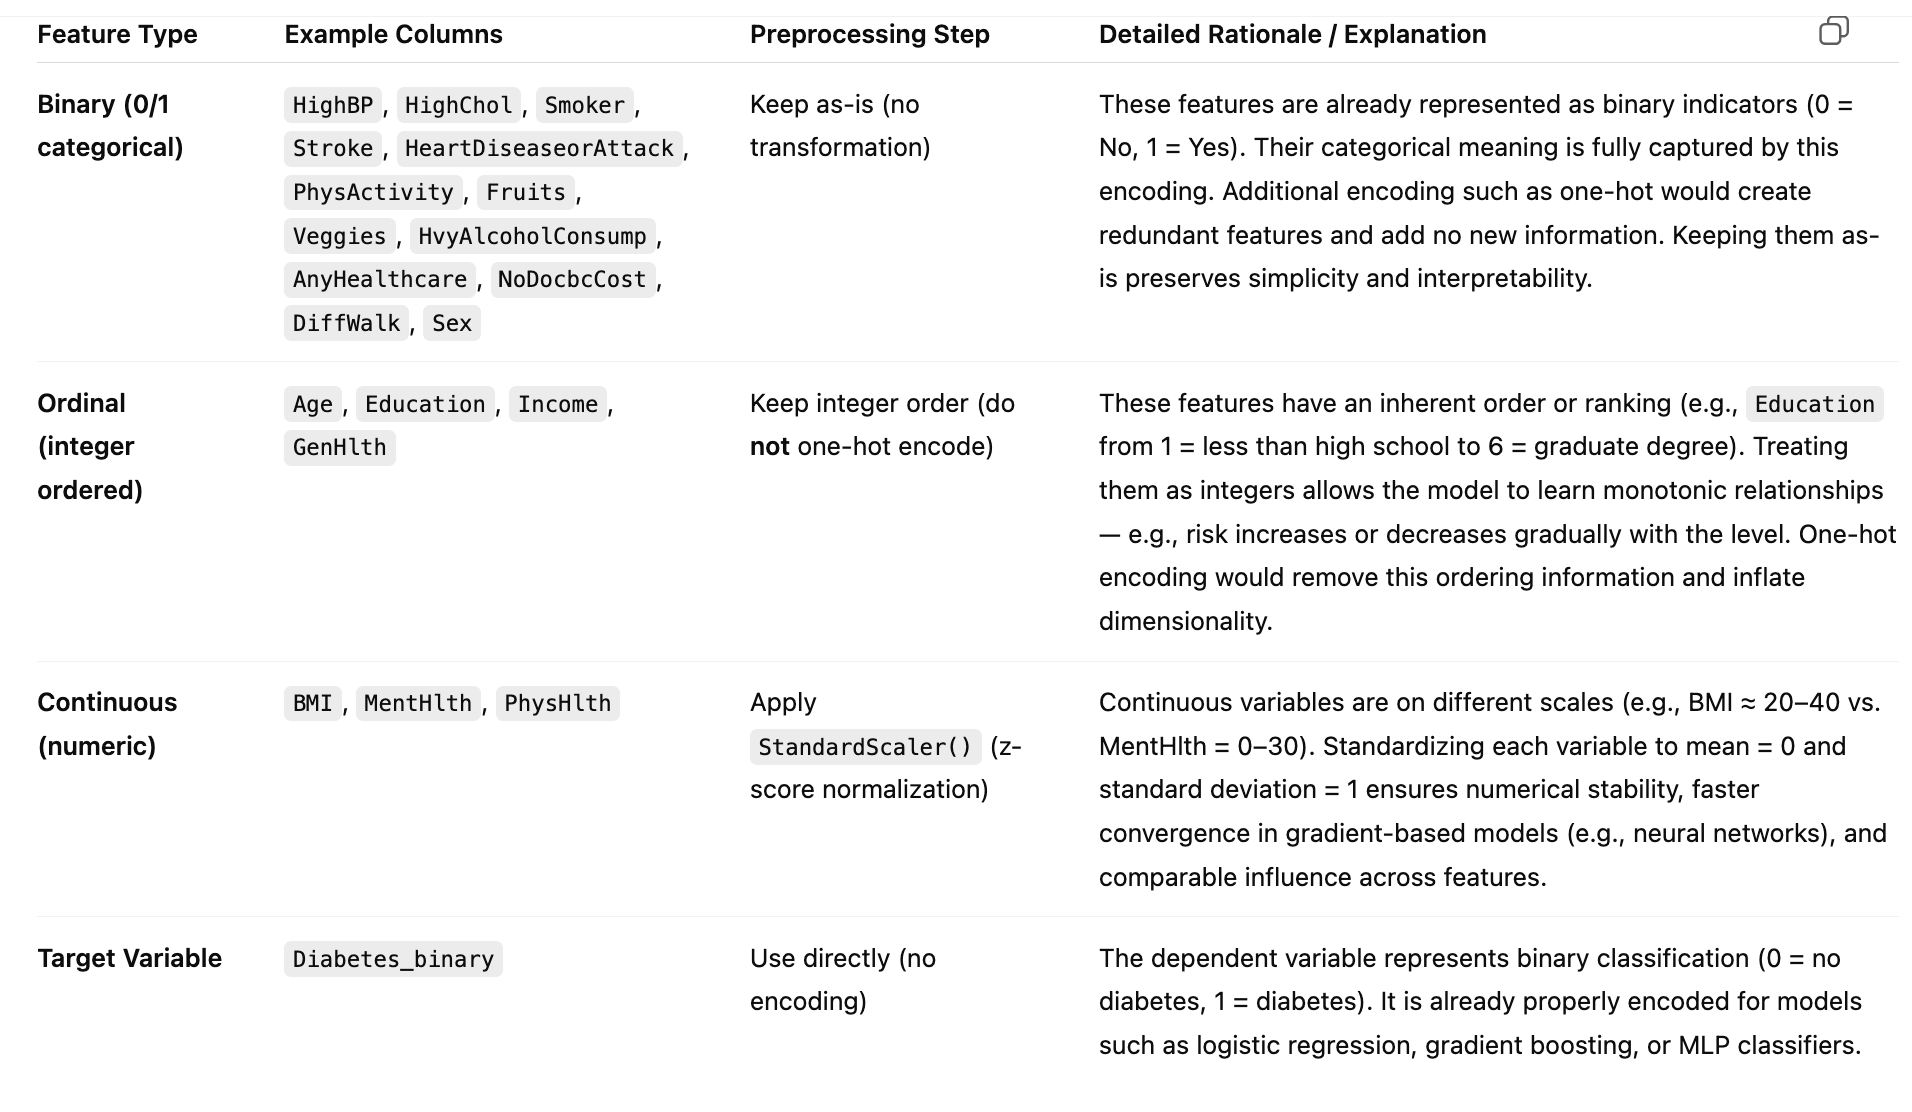

# **Feature selection**

 – mutual inforamtion calculation between target and features. Find the most related features with target

 – Pearson corrlation analysis between features for redundancy detection between features

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

# ============ 0) Configuration Section: Fill in your dataset column names ============
TARGET = "Diabetes_012"

BINARY_COLS = [
    "HighBP","HighChol","CholCheck","Smoker","Stroke","HeartDiseaseorAttack",
    "PhysActivity","Fruits","Veggies","HvyAlcoholConsump","AnyHealthcare",
    "NoDocbcCost","DiffWalk","Sex"
]

ORDINAL_COLS = ["GenHlth", "Age", "Education", "Income"]   # Ordinal integers
NUMERIC_COLS = ["BMI","MentHlth","PhysHlth"]               # Continuous numerical variables

ALL_FEATURES = BINARY_COLS + ORDINAL_COLS + NUMERIC_COLS

TOP_N = 15                 # Number of features to keep
REDUNDANCY_THRESHOLD = 0.6 # Redundancy threshold: two features with |corr| > 0.6 are considered redundant
# Previously set to 0.85; changed to 0.6 because most feature correlations are below 0.3

# ============ 1) Function: Compute Mutual Information & Pearson Correlation ============
def compute_feature_scores(df, target, features, numeric_cols):
    """
    Returns:
      - mi_df:  Mutual Information score table
      - corr_df: Pearson correlation with target (for numeric columns; if target is 0/1, it’s point-biserial correlation)
    """
    X = df[features].copy()
    y = df[target].astype(int).values

    # Ensure numeric data type (both MI and correlation require numeric input)
    for c in X.columns:
        X[c] = pd.to_numeric(X[c], errors="coerce")

    # Mutual Information (works for mixed types; approximates continuous data discretely)
    mi = mutual_info_classif(X.fillna(X.median(numeric_only=True)), y, discrete_features=False, random_state=42)
    mi_df = pd.DataFrame({"feature": X.columns, "mutual_info": mi}).sort_values("mutual_info", ascending=False)

    # Pearson correlation with the target (only for numeric columns)
    corr_with_y = {}
    for c in X.columns:
        # Require sufficient non-missing values
        s = X[c]
        mask = s.notna()
        if mask.sum() > 3:
            try:
                corr = np.corrcoef(s[mask].astype(float), y[mask])[0,1]
            except Exception:
                corr = np.nan
        else:
            corr = np.nan
        corr_with_y[c] = corr

    corr_df = pd.DataFrame({"feature": list(corr_with_y.keys()),
                            "pearson_to_y": list(corr_with_y.values())})
    corr_df = corr_df.sort_values("pearson_to_y", key=lambda s: s.abs(), ascending=False)

    return mi_df, corr_df

# ============ 2) Function: Plot Feature–Feature Correlation Heatmap (to check redundancy) ============
def plot_feature_corr_heatmap(df, features, title="Feature-Feature Correlation (abs)"):
    X = df[features].copy()
    # Convert to numeric
    for c in X.columns:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    corr = X.corr(numeric_only=True).abs()  # Take absolute value to show redundancy more clearly

    # --- Draw heatmap using matplotlib only (no seaborn dependency) ---
    fig, ax = plt.subplots(figsize=(max(8, len(features)*0.5), max(6, len(features)*0.5)))
    cax = ax.imshow(corr.values, interpolation='nearest')
    ax.set_title(title)
    ax.set_xticks(range(len(features)))
    ax.set_yticks(range(len(features)))
    ax.set_xticklabels(features, rotation=90)
    ax.set_yticklabels(features)

    # Add numeric correlation values on the heatmap
    for i in range(len(features)):
        for j in range(len(features)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}",
                    ha="center", va="center", color="black", fontsize=7)

    fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    return corr

# ============ 3) Function: Select Top N Non-Redundant Features Based on Importance ============
def pick_topN_nonredundant(mi_df, corr_matrix, top_n=10, redundancy_threshold=0.6): # threshold adjusted from 0.85 to 0.6
    """
    Strategy:
      1) Sort features by mutual information descendingly
      2) Iteratively add candidates; if any feature has |corr| > threshold with an already selected one, skip it (considered redundant)
    """
    selected = []
    for feat in mi_df["feature"].tolist():
        if len(selected) >= top_n:
            break
        # Check redundancy with already selected features
        is_redundant = False
        for s in selected:
            if abs(corr_matrix.loc[feat, s]) > redundancy_threshold:
                is_redundant = True
                break
        if not is_redundant:
            selected.append(feat)
    return selected

# ============ 4) —— Example Main Workflow (replace df with your DataFrame) ============
# df = pd.read_csv("your_data.csv")  # Replace with your own data loading method

def run_feature_screening(df):
    # Basic checks
    missing_cols = [c for c in [TARGET] + ALL_FEATURES if c not in df.columns]
    if missing_cols:
        raise ValueError(f"The following columns are missing from df: {missing_cols}")

    # Compute Mutual Information & Pearson correlation with target
    mi_df, corr_to_y_df = compute_feature_scores(
        df=df, target=TARGET, features=ALL_FEATURES, numeric_cols=NUMERIC_COLS
    )

    print("\n=== Top 15 Features by Mutual Information with Target ===")
    print(mi_df.head(21).to_string(index=False)) # changed to 21 to show more


    print("\n=== Top 15 Features by Absolute Pearson Correlation with Target ===")
    print(corr_to_y_df.head(21).to_string(index=False))

    # Plot the feature-feature correlation heatmap and return correlation matrix
    corr_matrix = plot_feature_corr_heatmap(df, ALL_FEATURES)

    # Select Top N non-redundant features (based on MI primarily)
    recommended = pick_topN_nonredundant(mi_df, corr_matrix, top_n=TOP_N, redundancy_threshold=REDUNDANCY_THRESHOLD)

    print(f"\n=== Recommended Top {TOP_N} Features (Mutual Info Priority, Redundancy Threshold={REDUNDANCY_THRESHOLD}) ===")
    print(recommended)

    # Return for programmatic use
    return {
        "mi_table": mi_df,
        "corr_to_target_table": corr_to_y_df,
        "feature_corr_matrix": corr_matrix,
        "recommended_features": recommended
    }

# ======= Usage =======
# result = run_feature_screening(df)
# final_features = result["recommended_features"]


# **Model Training (MLP)**

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# ==== 1) Column grouping ====
TARGET = "Diabetes_012"

BINARY_COLS = [
    "HighBP","HighChol","CholCheck","Smoker","Stroke","HeartDiseaseorAttack",
    "PhysActivity","Fruits","Veggies","HvyAlcoholConsump","AnyHealthcare",
    "NoDocbcCost","DiffWalk","Sex"
]
ORDINAL_COLS = ["GenHlth","Age","Education","Income"]
NUMERIC_COLS = ["BMI","MentHlth","PhysHlth"]

# Selected features, (Mutual information) MI > 0.02
selected_features = [
    'GenHlth','HighBP','AnyHealthcare','PhysActivity','CholCheck','HighChol',
    'Veggies','Fruits','BMI','Age','Smoker','Income','Sex','Education','DiffWalk'
]

def split_types_by_selection(selected):
    bin_used = [c for c in selected if c in BINARY_COLS]
    ord_used = [c for c in selected if c in ORDINAL_COLS]
    num_used = [c for c in selected if c in NUMERIC_COLS]
    return bin_used, ord_used, num_used

bin_used, ord_used, num_used = split_types_by_selection(selected_features)

def build_preprocessor(bin_cols, ord_cols, num_cols):
    ord_bin_pre = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ])
    num_pre = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    return ColumnTransformer(
        transformers=[
            ("ord_bin", ord_bin_pre, bin_cols + ord_cols),
            ("num",     num_pre,     num_cols),
        ],
        remainder="drop"
    )

preprocessor = build_preprocessor(bin_used, ord_used, num_used)

# ==== 2) Split dataset ====
all_needed = selected_features + [TARGET]
df_use = df[all_needed].copy()

X = df_use.drop(columns=[TARGET])
y = df_use[TARGET].astype(int).to_numpy().ravel()   # ensure it's 1-D

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, shuffle=True, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# ==== 3) Model (MLP) ====

clf = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", MLPClassifier(
        hidden_layer_sizes=(256, 128),   # Two hidden layers, first layer 256 neurons, second layer 128 neurons
        activation='relu',               # Activation function, options: 'tanh', 'logistic', 'relu'
        solver='adam',                   # Optimizer, options: 'sgd', 'adam', 'lbfgs'
        max_iter=500,                    # Max iterations (increasing can improve convergence stability)
        random_state=42,
        learning_rate_init=5e-4,
        batch_size=512,
        alpha=1e-3,  # If overfitting on majority class, try increasing alpha (e.g., 1e-4 → 1e-3) to add regularization
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15
    ))
])


clf.fit(X_train, y_train)

# ---- AUC helper function: compatible with binary/multiclass ----
def compute_auc(y_true, proba, model):
    classes = model.classes_
    y_true = np.asarray(y_true).ravel()
    if len(classes) == 2:
        # Select the probability column corresponding to the positive class; if your positive class is 1, it will automatically pick it
        pos_class = 1 if 1 in classes else classes[1]
        pos_idx = list(classes).index(pos_class)
        return roc_auc_score(y_true, proba[:, pos_idx])
    else:
        return roc_auc_score(y_true, proba, multi_class='ovr', average='macro')

# ---- Validation ----
val_pred  = clf.predict(X_val)
val_proba = clf.predict_proba(X_val)
val_auc   = compute_auc(y_val, val_proba, clf.named_steps['model'])

print("Validation AUC:", val_auc)
print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print(classification_report(y_val, val_pred, digits=3))

# ---- Test ----
test_pred  = clf.predict(X_test)
test_proba = clf.predict_proba(X_test)
test_auc   = compute_auc(y_test, test_proba, clf.named_steps['model'])

print("Test AUC:", test_auc)
print("Test Accuracy:", accuracy_score(y_test, test_pred))
print(classification_report(y_test, test_pred, digits=3))
